In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data.csv')
# df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_test_cleaned.csv')

In [3]:
df.isna().sum()

stop_id                          0
lat                              0
lon                              0
ward                             0
is_existing_stop                 0
nearest_node_degree              0
road_type                        0
distance_to_major_road           0
distance_to_nearest_stop         0
stops_within_500m                0
stops_within_1km                 0
pop_not_served_nearby            0
poverty_rate_weighted_pop        0
route_count_serving              0
trips_per_day                    0
avg_headway_minutes           3961
service_span_hours               0
routes_within_500m               0
avg_speed_daily                  0
avg_speed_peak                   0
avg_speed_offpeak                0
congestion_pct_daily             0
congestion_pct_peak              0
trip_count_daily                 0
trip_count_peak                  0
demand_variability_cv            0
dominant_congestion_level        0
ward_pct_access                  0
ward_population     

In [4]:
# Cell 2: Load data
# df = pd.read_csv('your_data.csv')
# df = your_dataframe

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['is_good_stop'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (8234, 40)

Target distribution:
is_good_stop
0    6325
1    1909
Name: count, dtype: int64

Missing values:
avg_headway_minutes    3961
ward_category           104
dtype: int64


In [5]:
# Cell 3: Handle missing values
num_cols = ['nearest_node_degree', 'distance_to_major_road', 'distance_to_nearest_stop', 
            'stops_within_500m', 'stops_within_1km', 'pop_not_served_nearby', 
            'poverty_rate_weighted_pop', 'route_count_serving', 'trips_per_day', 
            'avg_headway_minutes', 'service_span_hours', 'routes_within_500m',
            'avg_speed_daily', 'avg_speed_peak', 'avg_speed_offpeak', 
            'congestion_pct_daily', 'congestion_pct_peak', 'trip_count_daily', 
            'trip_count_peak', 'demand_variability_cv', 'ward_pct_access', 
            'ward_population', 'ward_poverty_rate', 'distance_to_cbd', 
            'coverage_efficiency_nearby', 'demand_supply_ratio', 'network_accessibility', 
            'pop_within_500m', 'trips_per_1k_pop_per_hour', 'subcounty_gini']

for col in num_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

cat_cols = ['ward', 'road_type', 'dominant_congestion_level', 'ward_category']
for col in cat_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled")

Missing values handled


In [6]:
df.columns

Index(['stop_id', 'lat', 'lon', 'ward', 'is_existing_stop',
       'nearest_node_degree', 'road_type', 'distance_to_major_road',
       'distance_to_nearest_stop', 'stops_within_500m', 'stops_within_1km',
       'pop_not_served_nearby', 'poverty_rate_weighted_pop',
       'route_count_serving', 'trips_per_day', 'avg_headway_minutes',
       'service_span_hours', 'routes_within_500m', 'avg_speed_daily',
       'avg_speed_peak', 'avg_speed_offpeak', 'congestion_pct_daily',
       'congestion_pct_peak', 'trip_count_daily', 'trip_count_peak',
       'demand_variability_cv', 'dominant_congestion_level', 'ward_pct_access',
       'ward_population', 'ward_poverty_rate', 'is_benchmark_ward',
       'ward_category', 'distance_to_cbd', 'coverage_efficiency_nearby',
       'demand_supply_ratio', 'network_accessibility', 'is_good_stop',
       'pop_within_500m', 'subcounty_gini', 'trips_per_1k_pop_per_hour'],
      dtype='object')

In [7]:
# Recreate proper labels based on stop-level features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize key features
df['pop_score'] = scaler.fit_transform(df[['pop_within_500m']])
df['coverage_score'] = scaler.fit_transform(df[['coverage_efficiency_nearby']])
df['access_score'] = 1 - scaler.fit_transform(df[['distance_to_nearest_stop']])
df['poverty_score'] = scaler.fit_transform(df[['poverty_rate_weighted_pop']])  # Higher poverty = more need

# Composite quality score
df['quality_score'] = (
    0.35 * df['pop_score'] +                    # Population coverage
    0.25 * df['coverage_score'] +               # Efficiency
    0.20 * df['access_score'] +                 # Accessibility
    0.20 * df['poverty_score']                  # Equity (serve poor areas)
)

# Label: top 25% are "good stops"
threshold = df['quality_score'].quantile(0.75)
df['is_good_stop'] = (df['quality_score'] > threshold).astype(int)

print("="*70)
print("NEW LABEL DISTRIBUTION BY WARD CATEGORY")
print("="*70)
result = df.groupby('ward_category')['is_good_stop'].agg(['sum', 'mean', 'count'])
result['pct'] = result['mean'] * 100
print(result)

print("\n" + "="*70)
print("LABEL DISTRIBUTION BY EXISTING vs CANDIDATE")
print("="*70)
result2 = df.groupby(['ward_category', 'is_existing_stop'])['is_good_stop'].agg(['sum', 'mean', 'count'])
print(result2)

# Save checkpoint
df.to_csv('df_with_proper_labels.csv', index=False)
print("\nSaved data with proper labels to df_with_proper_labels.csv")

NEW LABEL DISTRIBUTION BY WARD CATEGORY
                       sum      mean  count        pct
ward_category                                         
adequately_served      512  0.342475   1495  34.247492
severely_underserved    40  0.021575   1854   2.157497
underserved            247  0.116455   2121  11.645450
well_served           1260  0.455861   2764  45.586107

LABEL DISTRIBUTION BY EXISTING vs CANDIDATE
                                       sum      mean  count
ward_category        is_existing_stop                      
adequately_served    False             468  0.520000    900
                     True               44  0.073950    595
severely_underserved False              14  0.020000    700
                     True               26  0.022530   1154
underserved          False             196  0.217778    900
                     True               51  0.041769   1221
well_served          False             887  0.611724   1450
                     True              373  0

In [8]:
# Cell 4: Encode categorical features
encoded_dfs = []

for col in cat_cols:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
        encoded_dfs.append(dummies)

binary_cols = ['is_existing_stop', 'is_benchmark_ward']
for col in binary_cols:
    if col in df.columns:
        encoded_dfs.append(df[[col]].astype(float))

cat_features = pd.concat(encoded_dfs, axis=1)
print(f"Categorical features encoded: {cat_features.shape[1]} features")

Categorical features encoded: 102 features


In [9]:
# Cell 5: Scale numerical features
scaler = StandardScaler()
num_features = pd.DataFrame(
    scaler.fit_transform(df[num_cols]), 
    columns=num_cols,
    index=df.index
)

print(f"Numerical features scaled: {num_features.shape[1]} features")

Numerical features scaled: 30 features


In [10]:
# Cell 6 (REPLACE): Combine features - force numeric types
X = pd.concat([num_features, cat_features], axis=1)

# Convert all columns to numeric, coercing errors
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill any NaNs that resulted from coercion
X = X.fillna(0)

# Convert to numpy array with explicit float type
X = X.values.astype(np.float32)
y = df['is_good_stop'].values.astype(np.int64)

print(f"Final feature matrix: {X.shape}")
print(f"X dtype: {X.dtype}")
print(f"Target: {y.shape}")
print(f"y dtype: {y.dtype}")
print(f"Class balance: {np.bincount(y)}")

Final feature matrix: (8234, 132)
X dtype: float32
Target: (8234,)
y dtype: int64
Class balance: [6175 2059]


In [11]:
# Cell 7: Build spatial graph (RERUN THIS)
coords = df[['lat', 'lon']].values
tree = cKDTree(coords)

k_neighbors = 8
edge_list = []

for i in range(len(coords)):
    distances, neighbors = tree.query(coords[i], k=k_neighbors+1)
    neighbors = neighbors[1:]  # exclude self
    
    for j in neighbors:
        edge_list.append([i, j])
        edge_list.append([j, i])  # undirected

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# remove duplicates
edge_index = torch.unique(edge_index, dim=1)

print(f"Graph built: {len(coords)} nodes, {edge_index.shape[1]} edges")
print(f"Average degree: {edge_index.shape[1] / len(coords):.2f}")

Graph built: 8234 nodes, 80075 edges
Average degree: 9.72


In [12]:
# Cell 8: Create PyG data object and splits (RERUN THIS)
x = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y_tensor)

# train/val/test split
n_nodes = len(y)
indices = np.arange(n_nodes)

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)

train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}")

data = data.to(device)

Train: 5763 | Val: 1235 | Test: 1236


In [13]:
# Cell 9 (RERUN): Define GNN model - MUST RECREATE for new data size
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.lin = torch.nn.Linear(hidden_channels // 2, out_channels)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.lin(x)
        return x

model = GCN(in_channels=X.shape[1], hidden_channels=128, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input features: {X.shape[1]}")
print(f"Number of nodes: {len(y)}")

Model parameters: 41,922
Input features: 132
Number of nodes: 8234


In [14]:
# Cell 10: Training loop with class weights
import os

# Calculate class weights to handle imbalance
class_counts = np.bincount(y)
class_weights = torch.tensor([1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum()  # normalize

print(f"Class weights: {class_weights}")

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

best_val_f1 = 0
patience = 30
patience_counter = 0
save_path = 'best_model.pt'

for epoch in range(200):
    # Train
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)  # Added weight
    loss.backward()
    optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        
        # Train metrics
        train_pred = out[data.train_mask].argmax(1)
        train_acc = (train_pred == data.y[data.train_mask]).float().mean()
        
        # Val metrics
        val_pred = out[data.val_mask].argmax(1)
        val_acc = (val_pred == data.y[data.val_mask]).float().mean()
        val_loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask], weight=class_weights)  # Added weight
        
        val_f1 = f1_score(
            data.y[data.val_mask].cpu().numpy(),
            val_pred.cpu().numpy(),
            average='binary',
            zero_division=0
        )
    
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss.item())
    history['val_acc'].append(val_acc.item())
    history['val_f1'].append(val_f1)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Load best model
if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val F1: {best_val_f1:.4f}")
else:
    print(f"\nNo improvement, using final model. Val F1: {val_f1:.4f}")

Class weights: tensor([0.2501, 0.7499])
Epoch   0 | Train Loss: 0.6961 | Train Acc: 0.8416 | Val Acc: 0.8364 | Val F1: 0.7285
Epoch  10 | Train Loss: 0.2692 | Train Acc: 0.8745 | Val Acc: 0.8688 | Val F1: 0.7817
Epoch  20 | Train Loss: 0.2478 | Train Acc: 0.8850 | Val Acc: 0.8745 | Val F1: 0.7862
Epoch  30 | Train Loss: 0.2363 | Train Acc: 0.8863 | Val Acc: 0.8794 | Val F1: 0.7933
Epoch  40 | Train Loss: 0.2258 | Train Acc: 0.8850 | Val Acc: 0.8777 | Val F1: 0.7911
Epoch  50 | Train Loss: 0.2201 | Train Acc: 0.8777 | Val Acc: 0.8664 | Val F1: 0.7809

Early stopping at epoch 58

Best val F1: 0.7934


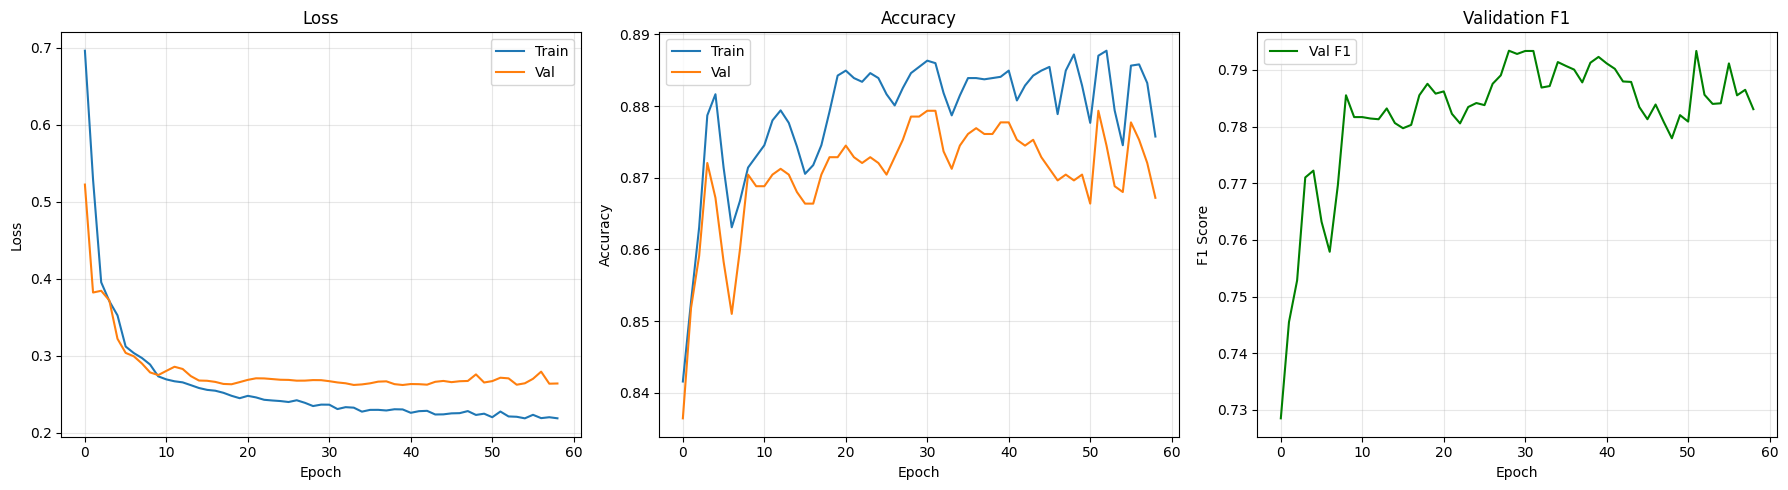

In [15]:
# Cell 11: Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_f1'], label='Val F1', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
plt.show()

Test Set Results:
              precision    recall  f1-score   support

         Bad       0.98      0.84      0.91       927
        Good       0.67      0.95      0.78       309

    accuracy                           0.87      1236
   macro avg       0.82      0.90      0.84      1236
weighted avg       0.90      0.87      0.88      1236



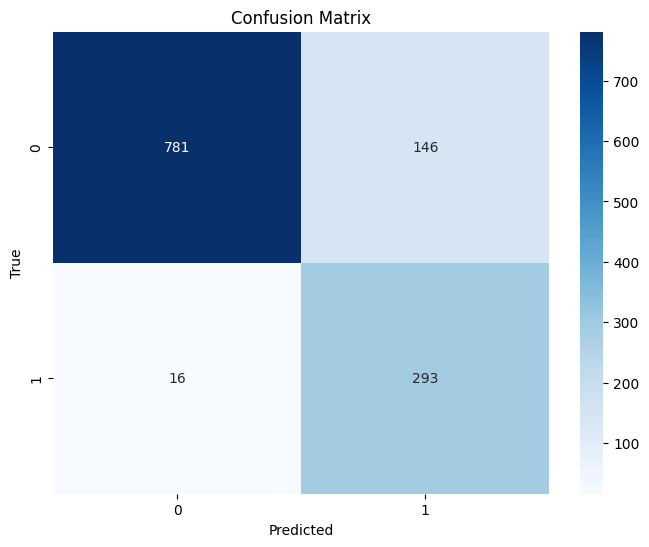

In [16]:
# Cell 12: Test set evaluation
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    test_pred = out[data.test_mask].argmax(1).cpu().numpy()
    test_true = data.y[data.test_mask].cpu().numpy()

print("Test Set Results:")
print(classification_report(test_true, test_pred, target_names=['Bad', 'Good']))

cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [17]:
# Cell 13: Generate predictions for all stops
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds = out.argmax(1).cpu().numpy()

df['gnn_probability'] = probs
df['gnn_prediction'] = preds
df['confidence'] = np.abs(probs - 0.5) * 2

print(f"\nPrediction statistics:")
print(f"Mean probability: {probs.mean():.3f}")
print(f"Std probability: {probs.std():.3f}")
print(f"Predicted good stops: {(preds == 1).sum()}")
print(f"Predicted bad stops: {(preds == 0).sum()}")


Prediction statistics:
Mean probability: 0.317
Std probability: 0.399
Predicted good stops: 2820
Predicted bad stops: 5414


In [18]:
print(f"\nPrediction probabilities by ward category:")
for cat in df['ward_category'].unique():
    subset = df[df['ward_category'] == cat]
    print(f"{cat}: mean={subset['gnn_probability'].mean():.3f}, "
          f"high_quality={((subset['gnn_probability'] > 0.7) & (subset['is_existing_stop'] == False)).sum()}")


Prediction probabilities by ward category:
well_served: mean=0.496, high_quality=998
underserved: mean=0.227, high_quality=331
severely_underserved: mean=0.085, high_quality=74
adequately_served: mean=0.398, high_quality=517


In [19]:
# Cell 14 (REPLACE): Get more candidates with lower thresholds
severely_under = df[
    (df['ward_category'] == 'severely_underserved') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.3)  # Very low threshold
].copy()

underserved = df[
    (df['ward_category'] == 'underserved') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.5)  # Medium threshold
].copy()

# Also get high-quality from adequately served (for comparison)
adequately = df[
    (df['ward_category'] == 'adequately_served') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.7)
].copy()

all_candidates = pd.concat([severely_under, underserved, adequately]).sort_values('gnn_probability', ascending=False)

print(f"Severely underserved (p>0.3): {len(severely_under)}")
print(f"Underserved (p>0.5): {len(underserved)}")
print(f"Adequately served (p>0.7): {len(adequately)}")
print(f"Total candidates: {len(all_candidates)}\n")

# Show distribution by ward
print("Candidates by ward:")
print(all_candidates.groupby('ward').size().sort_values(ascending=False).head(20))

print("\nTop 30 candidates:")
print(all_candidates[['stop_id', 'ward', 'ward_category', 'gnn_probability', 'pop_within_500m']].head(30))

all_candidates.to_csv('/home/dataopske/Desktop/jav/data/training_output/all_candidates_equity.csv', index=False)
print(f"\nSaved {len(all_candidates)} candidates to all_candidates_equity.csv")

Severely underserved (p>0.3): 139
Underserved (p>0.5): 441
Adequately served (p>0.7): 517
Total candidates: 1097

Candidates by ward:
ward
Dandora Area Iii Ward    50
Lucky Summer Ward        50
Korogocho Ward           50
Mathare North Ward       50
Eastleigh South Ward     49
Sarang'ombe Ward         48
Gatina Ward              48
Airbase Ward             47
Hospital Ward            46
Nyayo Highrise Ward      46
Kangemi Ward             45
Makina Ward              42
Kwa Njenga Ward          40
Pangani Ward             36
Nairobi West Ward        33
Ngando Ward              31
Mowlem Ward              31
Upper Savanna Ward       31
Kawangware Ward          29
Mountain View Ward       29
dtype: int64

Top 30 candidates:
                                             stop_id  \
7911                   CANDIDATE_Sarang'ombe Ward_27   
7915                   CANDIDATE_Sarang'ombe Ward_31   
7925                   CANDIDATE_Sarang'ombe Ward_41   
7891                    CANDIDATE_Sarang'omb

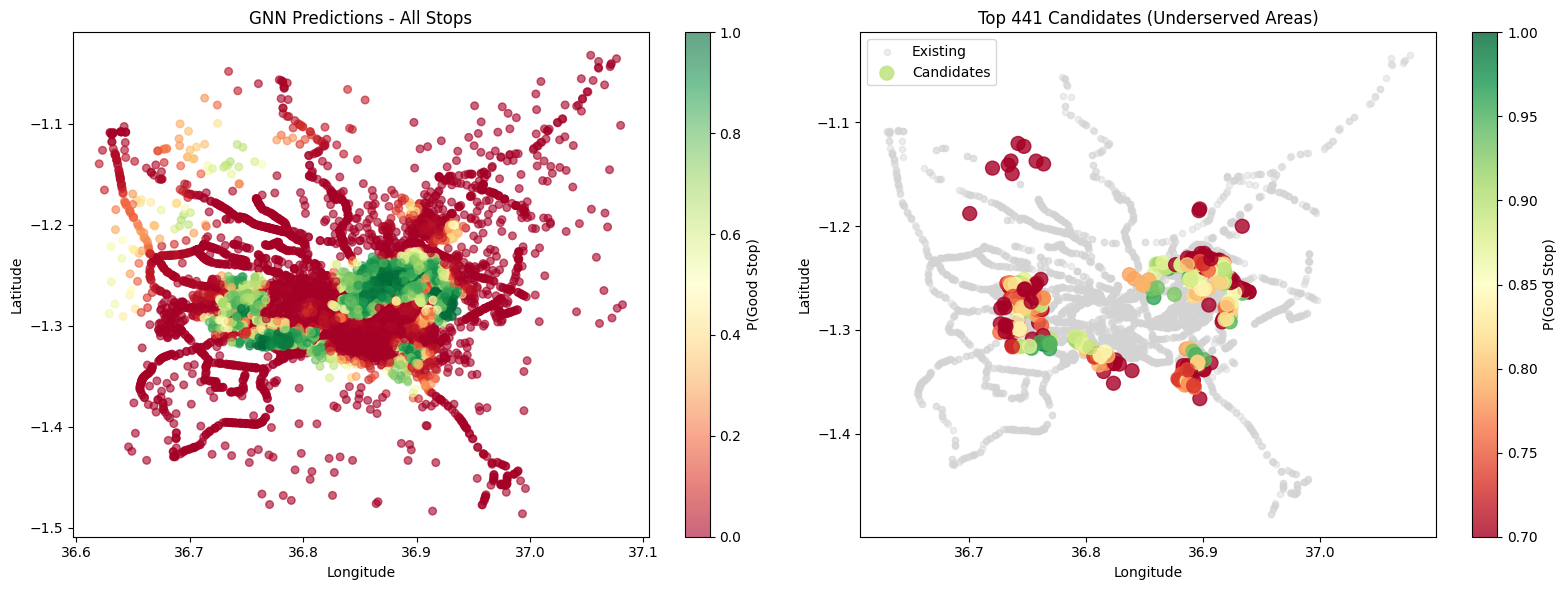

In [20]:
# Cell 15: Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All stops
scatter = axes[0].scatter(df['lon'], df['lat'], c=df['gnn_probability'], 
                         cmap='RdYlGn', s=30, alpha=0.6, vmin=0, vmax=1)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('GNN Predictions - All Stops')
plt.colorbar(scatter, ax=axes[0], label='P(Good Stop)')

# Top candidates
existing = df[df['is_existing_stop'] == True]
axes[1].scatter(existing['lon'], existing['lat'], c='lightgray', s=20, alpha=0.4, label='Existing')
if len(underserved) > 0:
    scatter = axes[1].scatter(underserved['lon'], underserved['lat'], 
                             c=underserved['gnn_probability'], cmap='RdYlGn', 
                             s=100, alpha=0.8, vmin=0.7, vmax=1.0, label='Candidates')
    plt.colorbar(scatter, ax=axes[1], label='P(Good Stop)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title(f'Top {len(underserved)} Candidates (Underserved Areas)')
axes[1].legend()

plt.tight_layout()
plt.savefig('spatial_predictions.png', dpi=300)
plt.show()

In [21]:
# Diagnostic: Check candidate distribution in training data
print("="*70)
print("TRAINING DATA DISTRIBUTION")
print("="*70)

for cat in ['severely_underserved', 'underserved', 'adequately_served', 'well_served']:
    subset = df[df['ward_category'] == cat]
    existing = subset[subset['is_existing_stop'] == True]
    candidates = subset[subset['is_existing_stop'] == False]
    
    print(f"\n{cat.upper()}:")
    print(f"  Total stops: {len(subset)}")
    print(f"  Existing stops: {len(existing)} ({len(existing)/len(subset)*100:.1f}%)")
    print(f"  Candidate stops: {len(candidates)} ({len(candidates)/len(subset)*100:.1f}%)")
    print(f"  Good existing: {existing['is_good_stop'].sum()}")
    print(f"  Good rate: {existing['is_good_stop'].mean()*100:.1f}%")

print("\n" + "="*70)
print("WARDS IN EACH CATEGORY:")
print("="*70)
for cat in df['ward_category'].unique():
    wards = df[df['ward_category'] == cat]['ward'].unique()
    print(f"\n{cat}: {len(wards)} wards")
    print(f"  {', '.join(wards[:5])}")
    if len(wards) > 5:
        print(f"  ... and {len(wards)-5} more")

TRAINING DATA DISTRIBUTION

SEVERELY_UNDERSERVED:
  Total stops: 1854
  Existing stops: 1154 (62.2%)
  Candidate stops: 700 (37.8%)
  Good existing: 26
  Good rate: 2.3%

UNDERSERVED:
  Total stops: 2121
  Existing stops: 1221 (57.6%)
  Candidate stops: 900 (42.4%)
  Good existing: 51
  Good rate: 4.2%

ADEQUATELY_SERVED:
  Total stops: 1495
  Existing stops: 595 (39.8%)
  Candidate stops: 900 (60.2%)
  Good existing: 44
  Good rate: 7.4%

WELL_SERVED:
  Total stops: 2764
  Existing stops: 1314 (47.5%)
  Candidate stops: 1450 (52.5%)
  Good existing: 373
  Good rate: 28.4%

WARDS IN EACH CATEGORY:

well_served: 29 wards
  Nairobi Central Ward, Ngara Ward Ward, Babandogo, Kariobangi North Ward, Parklands/highridge Ward
  ... and 24 more

underserved: 18 wards
  Kahawa, Karura Ward, Kitisuru Ward, Roysambu Ward, Clay City
  ... and 13 more

severely_underserved: 14 wards
  Kahawa West, Zimmerman Ward, Githurai Ward, Ruai Ward, Mwiki Ward
  ... and 9 more

adequately_served: 18 wards
  Ma

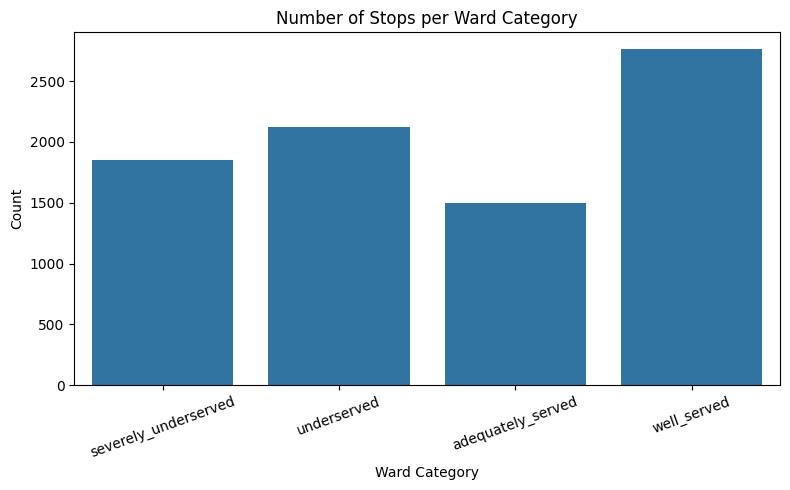

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='ward_category', order=[
    'severely_underserved','underserved','adequately_served','well_served'
])
plt.title("Number of Stops per Ward Category")
plt.ylabel("Count")
plt.xlabel("Ward Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

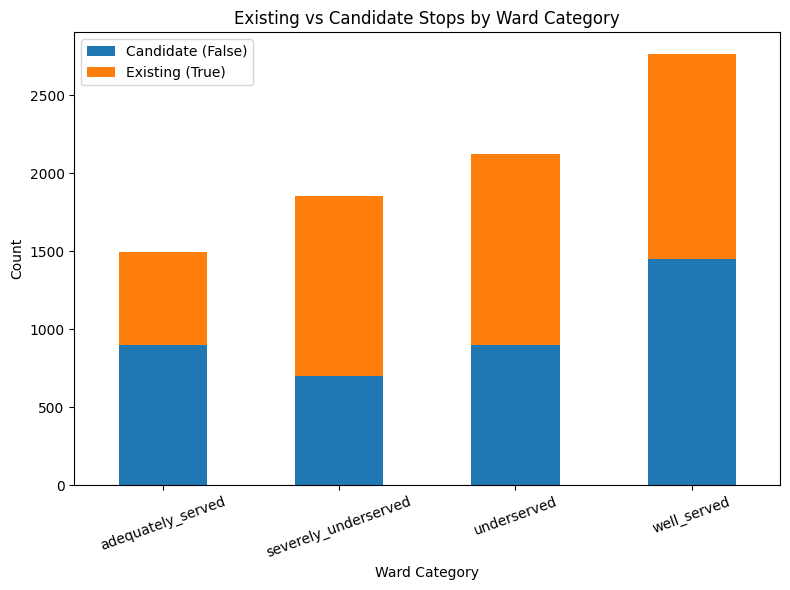

In [27]:
import pandas as pd

category_counts = df.groupby(['ward_category', 'is_existing_stop']).size().unstack().fillna(0)

category_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)
plt.title("Existing vs Candidate Stops by Ward Category")
plt.ylabel("Count")
plt.xlabel("Ward Category")
plt.xticks(rotation=20)
plt.legend(["Candidate (False)", "Existing (True)"])
plt.savefig("output2.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()


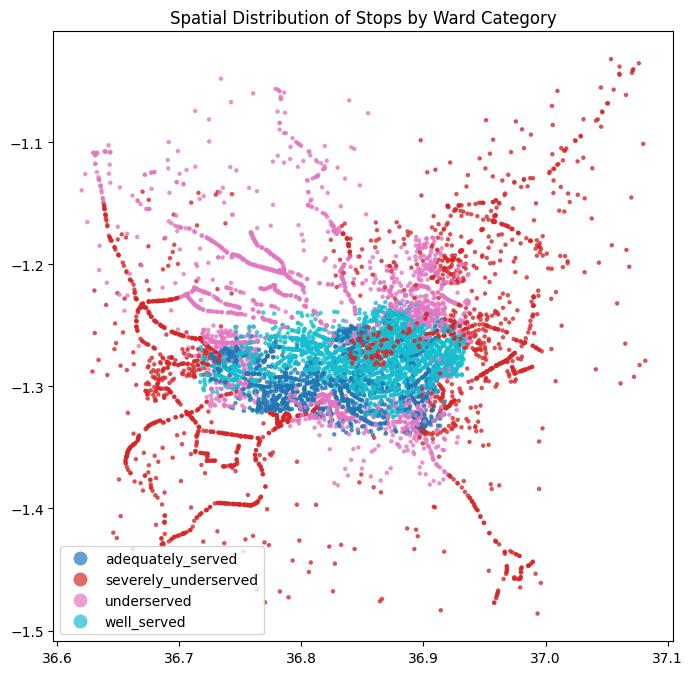

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat))

gdf.plot(
    column='ward_category',
    figsize=(8,8),
    markersize=5,
    legend=True,
    alpha=0.7
)
plt.title("Spatial Distribution of Stops by Ward Category")
plt.savefig("output.png", dpi=300, bbox_inches="tight")
plt.show()
